# 01 - Data Understanding and Exploratory Data Analysis

## Purpose

This notebook performs the initial data understanding and exploratory data analysis (EDA) for the SupplyPrescript predictive model.

The project requires a predictive baseline using XGBoost to predict shipment delays through classification and regression. :contentReference[oaicite:0]{index=0} :contentReference[oaicite:1]{index=1}

The processed Olist e-commerce dataset is examined to understand its structure, quality, variables, targets, dates, and potential data leakage before model preprocessing and training.

## Analysis Covered

- Load and inspect the processed dataset
- Understand dataset shape and columns
- Examine data types
- Check missing values and duplicates
- Analyze numerical and categorical features
- Examine the prediction targets
- Examine date-related information
- Identify potential data leakage
- Finalize the candidate ML features and targets

## Targets

- `delayed` — Classification target
- `delivery_delay_days` — Regression target

## Outcome / Leakage Information

- `order_delivered_customer_date` represents actual delivery information and must not be used as a prediction feature.

## Output

The findings and feature decisions from this notebook are used as the basis for the preprocessing stage in:

`02_preprocessing.ipynb`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../../data/processed/processed_orders.csv")
df.head(2)

,order_id,customer_id,customer_state,primary_seller_state,primary_category,item_count,product_count,seller_count,total_price,total_freight_value,...,avg_product_width_cm,avg_shipping_limit_days,purchase_year,purchase_month,purchase_dayofweek,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days,delayed
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,SP,PR,health_beauty,3,1,1,134.97,8.49,...,16.0,4.455,2016,9,3,2016-09-15 12:16:38,2016-10-04,2016-11-09 07:47:38,36.325,1
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,SP,PR,watches_gifts,1,1,1,29.90,15.56,...,16.0,18.280,2016,10,0,2016-10-03 09:44:50,2016-10-27,2016-10-26 14:02:13,-0.415,0


In [6]:
#Check shape of the dataset
df.shape

(96476, 25)

In [7]:
#Check columns + data types
print("Column names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

Column names:
['order_id', 'customer_id', 'customer_state', 'primary_seller_state', 'primary_category', 'item_count', 'product_count', 'seller_count', 'total_price', 'total_freight_value', 'total_order_value', 'avg_item_price', 'avg_product_weight_g', 'avg_product_length_cm', 'avg_product_height_cm', 'avg_product_width_cm', 'avg_shipping_limit_days', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'delivery_delay_days', 'delayed']

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 96476 entries, 0 to 96475
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96476 non-null  str    
 1   customer_id                    96476 non-null  str    
 2   customer_state                 96476 non-null  str    
 3   primary_seller_state      

In [8]:
# Check for missing values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

primary_category         1332
avg_product_weight_g       16
avg_product_length_cm      16
avg_product_height_cm      16
avg_product_width_cm       16
dtype: int64

In [9]:
# Check for completely duplicated rows
print("Duplicate rows:", df.duplicated().sum())

# Check for duplicate order IDs
print("Duplicate order IDs:", df["order_id"].duplicated().sum())

Duplicate rows: 0
Duplicate order IDs: 0


In [10]:
#Identify numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(numeric_cols.tolist())

Numerical columns:
['item_count', 'product_count', 'seller_count', 'total_price', 'total_freight_value', 'total_order_value', 'avg_item_price', 'avg_product_weight_g', 'avg_product_length_cm', 'avg_product_height_cm', 'avg_product_width_cm', 'avg_shipping_limit_days', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'delivery_delay_days', 'delayed']


In [11]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
item_count,96476.0,1.142212,0.538816,1.000,1.000,1.000,1.000,21.000
product_count,96476.0,1.038548,0.227965,1.000,1.000,1.000,1.000,8.000
seller_count,96476.0,1.013900,0.123538,1.000,1.000,1.000,1.000,5.000
total_price,96476.0,137.038176,209.047091,0.850,45.900,86.500,149.900,13440.000
total_freight_value,96476.0,22.785442,21.559394,0.000,13.850,17.170,24.020,1794.960
total_order_value,96476.0,159.823618,218.796209,9.590,61.850,105.280,176.260,13664.080
avg_item_price,96476.0,125.229853,189.699657,0.850,41.900,79.000,139.900,6735.000
avg_product_weight_g,96460.0,2098.206807,3744.917366,0.000,300.000,700.000,1800.000,40425.000
avg_product_length_cm,96460.0,30.085019,16.045020,7.000,18.000,25.000,38.000,105.000
avg_product_height_cm,96460.0,16.444882,13.240607,2.000,8.000,13.000,20.000,105.000


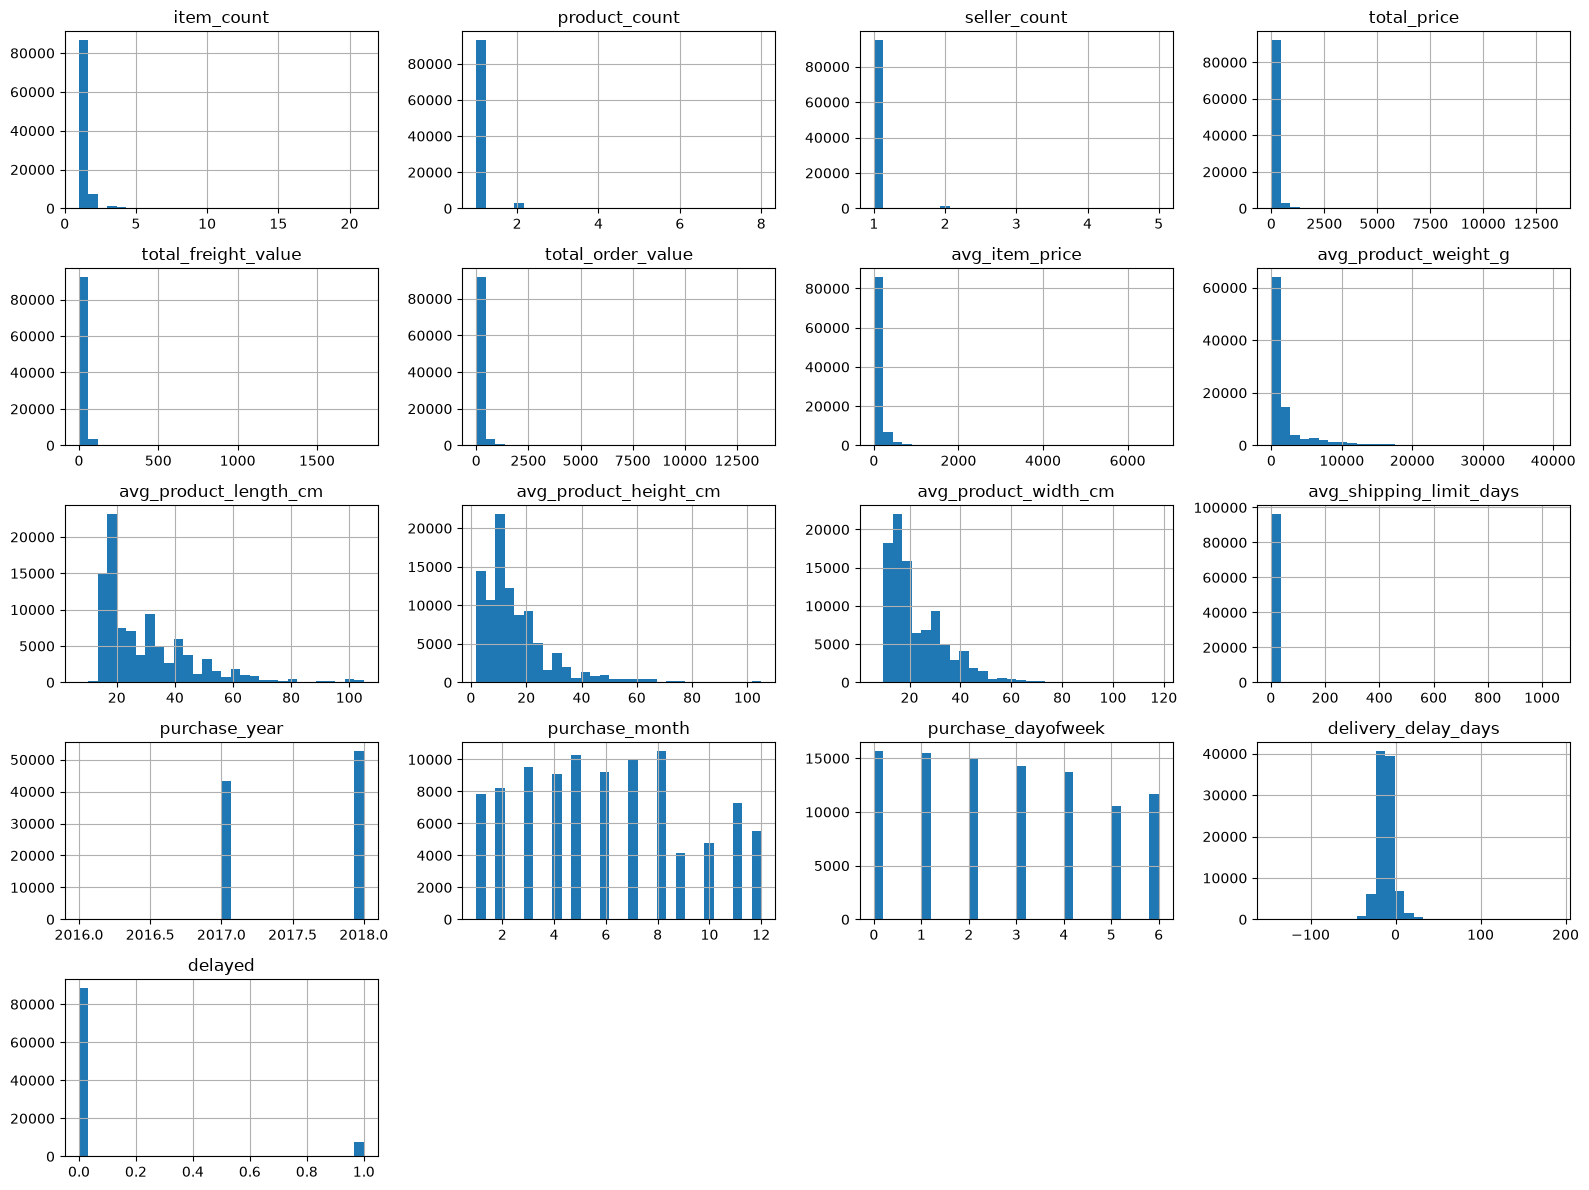

In [12]:
#Distribution of numerical columns 
df[numeric_cols].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

In [13]:
#Find categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols.tolist())

Categorical columns:
['order_id', 'customer_id', 'customer_state', 'primary_seller_state', 'primary_category', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'order_delivered_customer_date']


C:\Users\DELL\AppData\Local\Temp\ipykernel_20564\3487736869.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [14]:
#Number of unique values
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

order_id: 96476 unique values
customer_id: 96476 unique values
customer_state: 27 unique values
primary_seller_state: 22 unique values
primary_category: 73 unique values
order_purchase_timestamp: 95954 unique values
order_estimated_delivery_date: 445 unique values
order_delivered_customer_date: 95664 unique values


In [15]:
#See the actual categories
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(15))


--- order_id ---
order_id
bfbd0f9bdef84302105ad712db648a6c    1
3b697a20d9e427646d92567910af6d57    1
be5bc2f0da14d8071e2d45451ad119d9    1
65d1e226dfaeb8cdc42f665422522d14    1
a41c8759fbe7aab36ea07e038b2d4465    1
d207cc272675637bfed0062edffd0818    1
cd3b8574c82b42fc8129f6d502690c3e    1
ae8a60e4b03c5a4ba9ca0672c164b181    1
ef1b29b591d31d57c0d7337460dd83c9    1
0a0837a5eee9e7a9ce2b1fa831944d27    1
1ff217aa612f6cd7c4255c9bfe931c8b    1
ed8c7b1b3eb256c70ce0c74231e1da88    1
c3d9e402b6a0fbe2a5f7fc5b41117c38    1
46046adea0e222a29259bad3d922fee8    1
80606b26965c5ed21e85a085e0667b63    1
Name: count, dtype: int64

--- customer_id ---
customer_id
86dc2ffce2dfff336de2f386a786e574    1
355077684019f7f60a031656bd7262b8    1
7ec40b22510fdbea1b08921dd39e63d8    1
70fc57eeae292675927697fe03ad3ff5    1
6f989332712d3222b6571b1cf5b835ce    1
b8cf418e97ae795672d326288dfab7a7    1
7812fcebfc5e8065d31e1bb5f0017dae    1
e6f959bf384d1d53b6d68826699bba12    1
dc607dc98d6a11d5d04d9f2a70aa6c34    1
4f

In [16]:
#Examine the target variables - delayed column
print("Delayed value counts:")
print(df["delayed"].value_counts())

print("\nDelayed percentage:")
print(df["delayed"].value_counts(normalize=True).mul(100).round(2))

Delayed value counts:
delayed
0    88649
1     7827
Name: count, dtype: int64

Delayed percentage:
delayed
0    91.89
1     8.11
Name: proportion, dtype: float64


In [17]:
#Examine the target variables - delivery_delay_days column
print(df["delivery_delay_days"].describe())

print("Minimum delay:", df["delivery_delay_days"].min())
print("Maximum delay:", df["delivery_delay_days"].max())

count    96476.000000
mean       -11.179119
std         10.186113
min       -146.016000
25%        -16.244000
50%        -11.949000
75%         -6.390000
max        188.975000
Name: delivery_delay_days, dtype: float64
Minimum delay: -146.016
Maximum delay: 188.975


In [18]:
#How many are early/on-time/late
print("Early deliveries:", (df["delivery_delay_days"] < 0).sum())
print("On-time deliveries:", (df["delivery_delay_days"] == 0).sum())
print("Late deliveries:", (df["delivery_delay_days"] > 0).sum())

Early deliveries: 88648
On-time deliveries: 1
Late deliveries: 7827


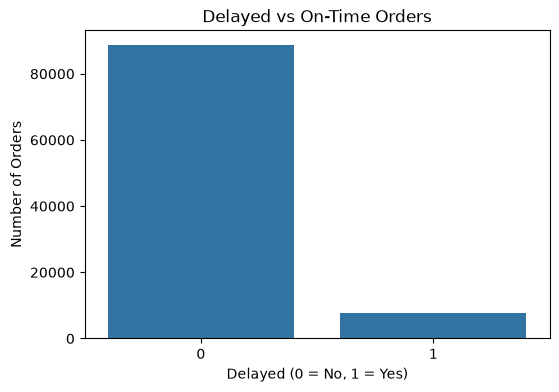

In [19]:
#Visualize the target
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="delayed")

plt.title("Delayed vs On-Time Orders")
plt.xlabel("Delayed (0 = No, 1 = Yes)")
plt.ylabel("Number of Orders")
plt.show()

In [ ]:
#Identify the date columns
date_cols = [
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "order_delivered_customer_date"
]

df[date_cols].head()

,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date
0,2016-09-15 12:16:38,2016-10-04,2016-11-09 07:47:38
1,2016-10-03 09:44:50,2016-10-27,2016-10-26 14:02:13
2,2016-10-03 16:56:50,2016-11-07,2016-10-27 18:19:38
3,2016-10-03 21:01:41,2016-11-25,2016-11-08 10:58:34
4,2016-10-03 21:13:36,2016-11-29,2016-11-03 10:58:07


In [21]:
#Converting dates temporarily for inspection
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_estimated_delivery_date    datetime64[us]
order_delivered_customer_date    datetime64[us]
dtype: object

In [22]:
#Check the date ranges
for col in date_cols:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


order_purchase_timestamp
Minimum: 2016-09-15 12:16:38
Maximum: 2018-08-29 15:00:37

order_estimated_delivery_date
Minimum: 2016-10-04 00:00:00
Maximum: 2018-10-25 00:00:00

order_delivered_customer_date
Minimum: 2016-10-11 13:46:32
Maximum: 2018-10-17 13:22:46


In [23]:
#Check missing dates
df[date_cols].isnull().sum()

order_purchase_timestamp         0
order_estimated_delivery_date    0
order_delivered_customer_date    0
dtype: int64

In [24]:
#Look at the three dates together
df[date_cols].head(10)

,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date
0,2016-09-15 12:16:38,2016-10-04,2016-11-09 07:47:38
1,2016-10-03 09:44:50,2016-10-27,2016-10-26 14:02:13
2,2016-10-03 16:56:50,2016-11-07,2016-10-27 18:19:38
3,2016-10-03 21:01:41,2016-11-25,2016-11-08 10:58:34
4,2016-10-03 21:13:36,2016-11-29,2016-11-03 10:58:07
5,2016-10-03 22:06:03,2016-11-23,2016-10-31 11:07:42
6,2016-10-03 22:31:31,2016-11-23,2016-10-14 16:08:00
7,2016-10-03 22:44:10,2016-12-01,2016-11-03 14:04:50
8,2016-10-03 22:51:30,2016-11-25,2016-11-01 15:14:45
9,2016-10-04 09:06:10,2016-11-24,2016-10-22 14:51:18


In [ ]:
#Check Data Leakage
#1. List all columns
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")


1. order_id
2. customer_id
3. customer_state
4. primary_seller_state
5. primary_category
6. item_count
7. product_count
8. seller_count
9. total_price
10. total_freight_value
11. total_order_value
12. avg_item_price
13. avg_product_weight_g
14. avg_product_length_cm
15. avg_product_height_cm
16. avg_product_width_cm
17. avg_shipping_limit_days
18. purchase_year
19. purchase_month
20. purchase_dayofweek
21. order_purchase_timestamp
22. order_estimated_delivery_date
23. order_delivered_customer_date
24. delivery_delay_days
25. delayed


In [ ]:
#2. Explicitly identify outcome/target columns
target_cols = [
    "delivery_delay_days",
    "delayed"
]

outcome_cols = [
    "order_delivered_customer_date"
]

print("Target columns:")
print(target_cols)

print("\nOutcome information:")
print(outcome_cols)

Target columns:
['delivery_delay_days', 'delayed']

Outcome information:
['order_delivered_customer_date']


In [ ]:
#3. Check whether delay was derived from the actual delivery date
calculated_delay = (
    df["order_delivered_customer_date"]
    - df["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

difference = (
    calculated_delay - df["delivery_delay_days"]
).abs()

print("Maximum difference:", difference.max())
print("Rows with difference > 0.01 days:", (difference > 0.01).sum())

Maximum difference: 0.0005000000000023874
Rows with difference > 0.01 days: 0


In [ ]:
#4. Check whether delayed agrees with positive delay
calculated_delayed = (df["delivery_delay_days"] > 0).astype(int)

print(
    "Rows where delayed target does not match delay days:",
    (calculated_delayed != df["delayed"]).sum()
)

Rows where delayed target does not match delay days: 0


In [30]:
#Finalize ML Features
#Define the ML feature candidates and target columns for the next preprocessing stage.

feature_cols = [
    "customer_state",
    "primary_seller_state",
    "primary_category",
    "item_count",
    "product_count",
    "seller_count",
    "total_price",
    "total_freight_value",
    "total_order_value",
    "avg_item_price",
    "avg_product_weight_g",
    "avg_product_length_cm",
    "avg_product_height_cm",
    "avg_product_width_cm",
    "avg_shipping_limit_days",
    "purchase_year",
    "purchase_month",
    "purchase_dayofweek",
    "order_purchase_timestamp",
    "order_estimated_delivery_date"
]

target_classification = "delayed"
target_regression = "delivery_delay_days"

print("Number of ML feature candidates:", len(feature_cols))
print("\nML features:")
print(feature_cols)

print("\nClassification target:", target_classification)
print("Regression target:", target_regression)

Number of ML feature candidates: 20

ML features:
['customer_state', 'primary_seller_state', 'primary_category', 'item_count', 'product_count', 'seller_count', 'total_price', 'total_freight_value', 'total_order_value', 'avg_item_price', 'avg_product_weight_g', 'avg_product_length_cm', 'avg_product_height_cm', 'avg_product_width_cm', 'avg_shipping_limit_days', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'order_purchase_timestamp', 'order_estimated_delivery_date']

Classification target: delayed
Regression target: delivery_delay_days
